##  Extract Frames from Videos

In [ ]:
import cv2
import os

# Define cropping parameters
crop_top = 35   
crop_bottom = 35   
crop_left = 55    
crop_right = 45  

def crop_video(input_path, output_path):
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f"Failed to open {input_path}")
        return

    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) 
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Define new cropped frame size
    new_width = width - crop_left - crop_right
    new_height = height - crop_top - crop_bottom

    if new_width <= 0 or new_height <= 0:
        print(f"Invalid crop dimensions for {input_path}. Skipping...")
        return

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (new_width, new_height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Crop the frame
        cropped_frame = frame[crop_top:height-crop_bottom, crop_left:width-crop_right]
        out.write(cropped_frame)

    cap.release()
    out.release()
    print(f"Cropped video saved: {output_path}")

def crop_videos_in_folder(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    for video_file in os.listdir(input_folder):
        if video_file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            input_path = os.path.join(input_folder, video_file)
            output_path = os.path.join(output_folder, f"cropped_{video_file}")
            crop_video(input_path, output_path)

# Example usage
input_folder = "dataset/video_only"  # Folder containing videos
output_folder = "cropped_videos"  # Folder to save cropped videos
crop_videos_in_folder(input_folder, output_folder)


Processed: dataset/video_only\video_only_ID_1.mp4
Processed: dataset/video_only\video_only_ID_10.mp4
Processed: dataset/video_only\video_only_ID_11.mp4
Processed: dataset/video_only\video_only_ID_12.mp4
Processed: dataset/video_only\video_only_ID_13.mp4
Processed: dataset/video_only\video_only_ID_14.mp4
Processed: dataset/video_only\video_only_ID_15.mp4
Processed: dataset/video_only\video_only_ID_16.mp4
Processed: dataset/video_only\video_only_ID_17.mp4
Processed: dataset/video_only\video_only_ID_18.mp4
Processed: dataset/video_only\video_only_ID_19.mp4
Processed: dataset/video_only\video_only_ID_2.mp4
Processed: dataset/video_only\video_only_ID_20.mp4
Processed: dataset/video_only\video_only_ID_21.mp4
Processed: dataset/video_only\video_only_ID_22.mp4
Processed: dataset/video_only\video_only_ID_23.mp4
Processed: dataset/video_only\video_only_ID_24.mp4
Processed: dataset/video_only\video_only_ID_25.mp4
Processed: dataset/video_only\video_only_ID_26.mp4
Processed: dataset/video_only\vid

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Function to extract frames and calculate video length
def extract_frames_and_length(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    # Get video length in seconds
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    vid_len = frame_count / fps if fps > 0 else 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    
    cap.release()
    return frames, vid_len

# Placeholder for video file path
video_path = 'cropped_videos/cropped_video_only_ID_1.mp4'  # Replace with the actual video file path
frames, vid_len = extract_frames_and_length(video_path)


In [54]:
def calculate_average_pixel_value(frames):
    average_values = []
    
    for frame in frames:
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        avg_pixel_value = np.mean(gray_frame)
        average_values.append(avg_pixel_value)
    
    return average_values

average_values = calculate_average_pixel_value(frames)


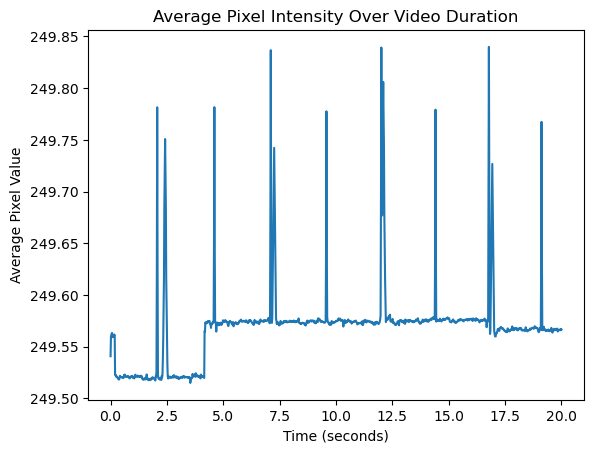

In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate average pixel values for frames
def calculate_average_pixel_value(frames):
    average_values = []
    
    for frame in frames:
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        avg_pixel_value = np.mean(gray_frame)
        average_values.append(avg_pixel_value)
    
    return average_values

# Function to extract frames and calculate video length
def extract_frames_and_length(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    # Get video length in seconds
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    vid_len = frame_count / fps if fps > 0 else 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    
    cap.release()
    return frames, vid_len

# Placeholder for video file path
video_path = 'cropped_videos/cropped_video_only_ID_18.mp4'  # Replace with actual video file path
frames, vid_len = extract_frames_and_length(video_path)

# Calculate average pixel values
average_values = calculate_average_pixel_value(frames)

# Normalize time scale from 0 to vid_len
frame_indices = np.linspace(0, vid_len, len(average_values))

# Plot the average pixel values over time
plt.plot(frame_indices, average_values)
plt.xlabel("Time (seconds)")
plt.ylabel("Average Pixel Value")
plt.title("Average Pixel Intensity Over Video Duration")
plt.show()


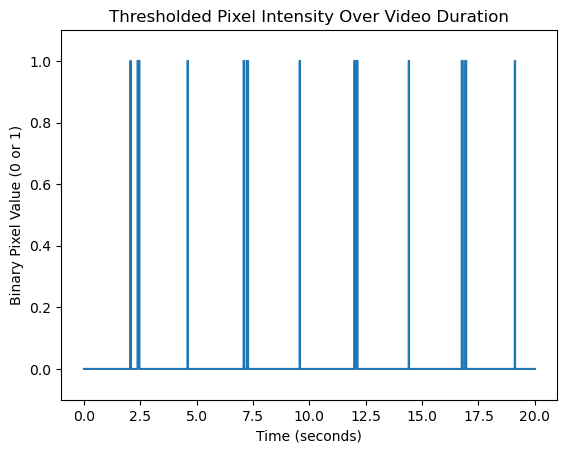

In [74]:
threshold = max(average_values) - (max(average_values) - min(average_values)) * 0.5
binary_values = [1 if val > threshold else 0 for val in average_values]


# Normalize time scale from 0 to vid_len
frame_indices = np.linspace(0, vid_len, len(binary_values))

# Plot the binary results over time
plt.step(frame_indices, binary_values, where='mid')  # Step plot for binary data
plt.xlabel("Time (seconds)")
plt.ylabel("Binary Pixel Value (0 or 1)")
plt.title("Thresholded Pixel Intensity Over Video Duration")
plt.ylim(-0.1, 1.1)  # Keep y-axis clean for binary values
plt.show()

## Audio File

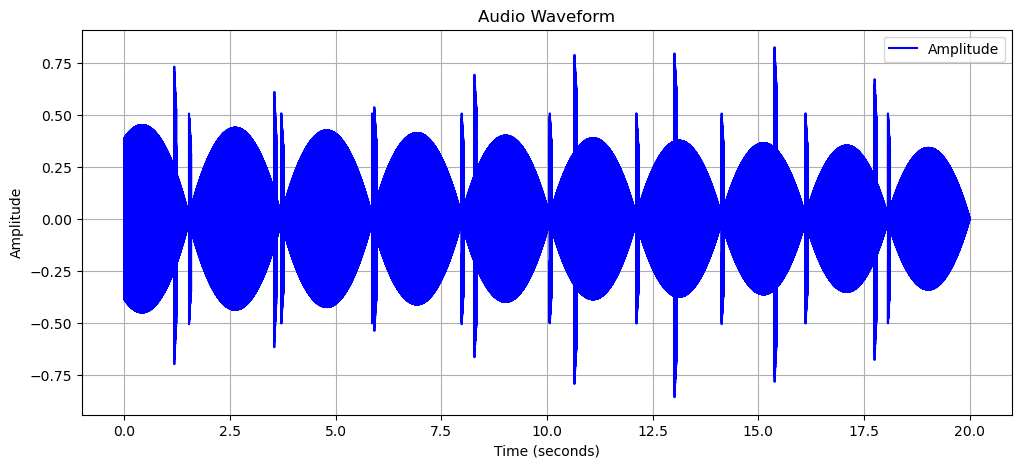

In [67]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def plot_audio_amplitude(audio_file):
    # Load audio file
    y, sr = librosa.load(audio_file, sr=None)  # Load with original sample rate

    # Create time axis
    time = np.linspace(0, len(y) / sr, num=len(y))

    # Plot amplitude waveform
    plt.figure(figsize=(12, 5))
    plt.plot(time, y, label="Amplitude", color="b")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("Audio Waveform")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
audio_file = "dataset/audio_only/audio_only_ID_18.wav"  # Replace with your file path
plot_audio_amplitude(audio_file)


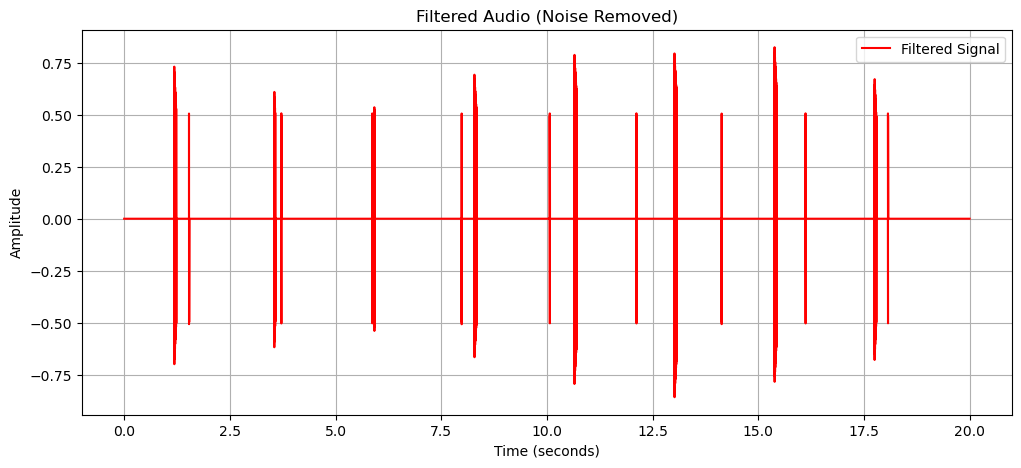

In [80]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

def plot_filtered_audio(audio_file, threshold=0.5):
    # Load audio file
    y, sr = librosa.load(audio_file, sr=None)

    # Apply thresholding: set values between -threshold and +threshold to zero
    y_filtered = np.where(np.abs(y) < threshold, 0, y)

    # Identify peak positions after filtering

    # Create time axis
    time = np.linspace(0, len(y) / sr, num=len(y))

    # Plot the processed waveform
    plt.figure(figsize=(12, 5))
    plt.plot(time, y_filtered, label="Filtered Signal", color="r")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title("Filtered Audio (Noise Removed)")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage
audio_file = "dataset/audio_only/audio_only_ID_18.wav"  # Replace with your file path
plot_filtered_audio(audio_file, threshold=0.49)


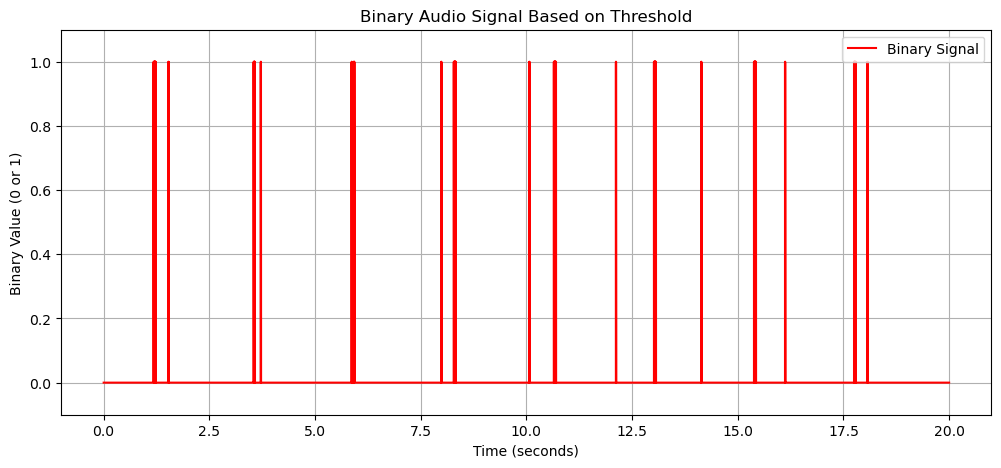

In [82]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def plot_binary_audio(audio_file, threshold=0.5):
    # Load audio file
    y, sr = librosa.load(audio_file, sr=None)

    # Apply thresholding: set values to 1 if greater than threshold, else 0
    y_binary = np.where(np.abs(y) > threshold, 1, 0)

    # Create time axis
    time = np.linspace(0, len(y) / sr, num=len(y))

    # Plot the binary waveform
    plt.figure(figsize=(12, 5))
    plt.step(time, y_binary, where="mid", label="Binary Signal", color="r")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Binary Value (0 or 1)")
    plt.title("Binary Audio Signal Based on Threshold")
    plt.legend()
    plt.grid()
    plt.ylim(-0.1, 1.1)  # Keep y-axis clean for binary values
    plt.show()

# Example usage
audio_file = "dataset/audio_only/audio_only_ID_18.wav"  # Replace with your file path
plot_binary_audio(audio_file, threshold=0.49)
